# EDA Solar Power Generation Data

Notebook nay chi thuc hien khai pha du lieu, tien xu li va ghep noi du lieu o cap plant/timestamp. Notebook khong huan luyen mo hinh.

## 1. Khoi tao moi truong

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'datasets'
API_WEATHER_DIR = DATA_DIR / 'api_weather'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLANTS = [1, 2]

## 2. Ham tien xu li dung chung

In [36]:
def resolve_dataset_path(filename: str) -> Path:
    dataset_path = DATA_DIR / filename
    if dataset_path.exists():
        return dataset_path
    fallback_path = BASE_DIR / filename
    if fallback_path.exists():
        return fallback_path
    raise FileNotFoundError(f'Khong tim thay dataset: {filename}')


def parse_generation_datetime(series: pd.Series, plant_no: int) -> pd.Series:
    if plant_no == 1:
        return pd.to_datetime(series, format='%d-%m-%Y %H:%M', errors='coerce')
    return pd.to_datetime(series, errors='coerce')


def load_plant_data(plant_no: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    generation = pd.read_csv(resolve_dataset_path(f'Plant_{plant_no}_Generation_Data.csv'))
    weather = pd.read_csv(resolve_dataset_path(f'Plant_{plant_no}_Weather_Sensor_Data.csv'))

    generation['DATE_TIME'] = parse_generation_datetime(generation['DATE_TIME'], plant_no)
    weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'], errors='coerce')
    generation['PLANT_NO'] = plant_no
    weather['PLANT_NO'] = plant_no

    if generation['DATE_TIME'].isna().any() or weather['DATE_TIME'].isna().any():
        raise ValueError(f'Loi parse DATE_TIME o Plant {plant_no}')

    generation = generation.sort_values(['DATE_TIME', 'SOURCE_KEY']).reset_index(drop=True)
    weather = weather.sort_values(['DATE_TIME']).reset_index(drop=True)
    return generation, weather


def aggregate_generation(generation: pd.DataFrame) -> pd.DataFrame:
    out = (
        generation.groupby(['PLANT_ID', 'PLANT_NO', 'DATE_TIME'], as_index=False)
        .agg(
            DC_POWER_TOTAL=('DC_POWER', 'sum'),
            AC_POWER_TOTAL=('AC_POWER', 'sum'),
            DAILY_YIELD_TOTAL=('DAILY_YIELD', 'sum'),
            TOTAL_YIELD_TOTAL=('TOTAL_YIELD', 'sum'),
            ACTIVE_SOURCE_COUNT=('SOURCE_KEY', 'nunique'),
            ZERO_AC_COUNT=('AC_POWER', lambda s: int((s == 0).sum())),
        )
    )
    out['ZERO_AC_RATIO'] = out['ZERO_AC_COUNT'] / out['ACTIVE_SOURCE_COUNT'].replace(0, np.nan)
    return out


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['HOUR'] = out['DATE_TIME'].dt.hour
    out['MINUTE'] = out['DATE_TIME'].dt.minute
    out['DAY'] = out['DATE_TIME'].dt.day
    out['DAYOFWEEK'] = out['DATE_TIME'].dt.dayofweek
    out['WEEKOFYEAR'] = out['DATE_TIME'].dt.isocalendar().week.astype(int)
    out['MONTH'] = out['DATE_TIME'].dt.month
    out['DAYOFYEAR'] = out['DATE_TIME'].dt.dayofyear
    hour_fraction = out['HOUR'] + out['MINUTE'] / 60.0
    out['HOUR_SIN'] = np.sin(2 * np.pi * hour_fraction / 24.0)
    out['HOUR_COS'] = np.cos(2 * np.pi * hour_fraction / 24.0)
    out['IS_DAYLIGHT'] = out['HOUR'].between(6, 18).astype(int)
    return out

## 3. Doc du lieu goc

In [37]:
generation_frames = []
weather_frames = []

for plant_no in PLANTS:
    gen, weather = load_plant_data(plant_no)
    generation_frames.append(gen)
    weather_frames.append(weather)

generation = pd.concat(generation_frames, ignore_index=True)
weather_sensor = pd.concat(weather_frames, ignore_index=True)

display(generation.head())
display(weather_sensor.head())

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_NO
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,1
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,1
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,1
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,1
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,1


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_NO
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,1
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,1
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,1
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,1
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,1


## 4. Kham pha cau truc du lieu

In [38]:
overview = pd.DataFrame(
    [
        {
            'table': 'generation',
            'rows': len(generation),
            'columns': generation.shape[1],
            'plants': generation['PLANT_NO'].nunique(),
            'timestamps': generation['DATE_TIME'].nunique(),
            'start': generation['DATE_TIME'].min(),
            'end': generation['DATE_TIME'].max(),
        },
        {
            'table': 'weather_sensor',
            'rows': len(weather_sensor),
            'columns': weather_sensor.shape[1],
            'plants': weather_sensor['PLANT_NO'].nunique(),
            'timestamps': weather_sensor['DATE_TIME'].nunique(),
            'start': weather_sensor['DATE_TIME'].min(),
            'end': weather_sensor['DATE_TIME'].max(),
        },
    ]
)

display(overview)
display(generation.dtypes.rename('dtype').to_frame())
display(weather_sensor.dtypes.rename('dtype').to_frame())

,table,rows,columns,plants,timestamps,start,end
0,generation,136476,8,2,3263,2020-05-15,2020-06-17 23:45:00
1,weather_sensor,6441,7,2,3262,2020-05-15,2020-06-17 23:45:00


,dtype
DATE_TIME,datetime64[ns]
PLANT_ID,int64
SOURCE_KEY,object
DC_POWER,float64
AC_POWER,float64
DAILY_YIELD,float64
TOTAL_YIELD,float64
PLANT_NO,int64


,dtype
DATE_TIME,datetime64[ns]
PLANT_ID,int64
SOURCE_KEY,object
AMBIENT_TEMPERATURE,float64
MODULE_TEMPERATURE,float64
IRRADIATION,float64
PLANT_NO,int64


In [39]:
missing_generation = generation.isna().sum().rename('missing').to_frame()
missing_weather = weather_sensor.isna().sum().rename('missing').to_frame()

duplicate_generation_keys = generation.duplicated(['PLANT_ID', 'PLANT_NO', 'DATE_TIME', 'SOURCE_KEY']).sum()
duplicate_weather_keys = weather_sensor.duplicated(['PLANT_ID', 'PLANT_NO', 'DATE_TIME']).sum()

print('Duplicate generation keys:', duplicate_generation_keys)
print('Duplicate weather timestamp keys:', duplicate_weather_keys)
display(missing_generation)
display(missing_weather)

Duplicate generation keys: 0
Duplicate weather timestamp keys: 0


,missing
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0
PLANT_NO,0


,missing
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0
PLANT_NO,0


## 5. Thong ke theo plant

In [40]:
generation_summary = generation.groupby('PLANT_NO').agg(
    rows=('DATE_TIME', 'size'),
    timestamps=('DATE_TIME', 'nunique'),
    inverters=('SOURCE_KEY', 'nunique'),
    ac_mean=('AC_POWER', 'mean'),
    ac_max=('AC_POWER', 'max'),
    dc_mean=('DC_POWER', 'mean'),
    zero_ac_ratio=('AC_POWER', lambda s: float((s == 0).mean())),
)

weather_summary = weather_sensor.groupby('PLANT_NO').agg(
    rows=('DATE_TIME', 'size'),
    timestamps=('DATE_TIME', 'nunique'),
    ambient_mean=('AMBIENT_TEMPERATURE', 'mean'),
    module_mean=('MODULE_TEMPERATURE', 'mean'),
    irradiation_mean=('IRRADIATION', 'mean'),
    irradiation_max=('IRRADIATION', 'max'),
)

display(generation_summary)
display(weather_summary)

,rows,timestamps,inverters,ac_mean,ac_max,dc_mean,zero_ac_ratio
PLANT_NO,,,,,,,
1,68778,3158,22,307.802752,1410.95,3147.426211,0.464553
2,67698,3259,22,241.277825,1385.42,246.701961,0.526781


,rows,timestamps,ambient_mean,module_mean,irradiation_mean,irradiation_max
PLANT_NO,,,,,,
1,3182,3182,25.531606,31.091015,0.228313,1.221652
2,3259,3259,28.069400,32.772408,0.232737,1.098766


## 6. Truc quan EDA co ban

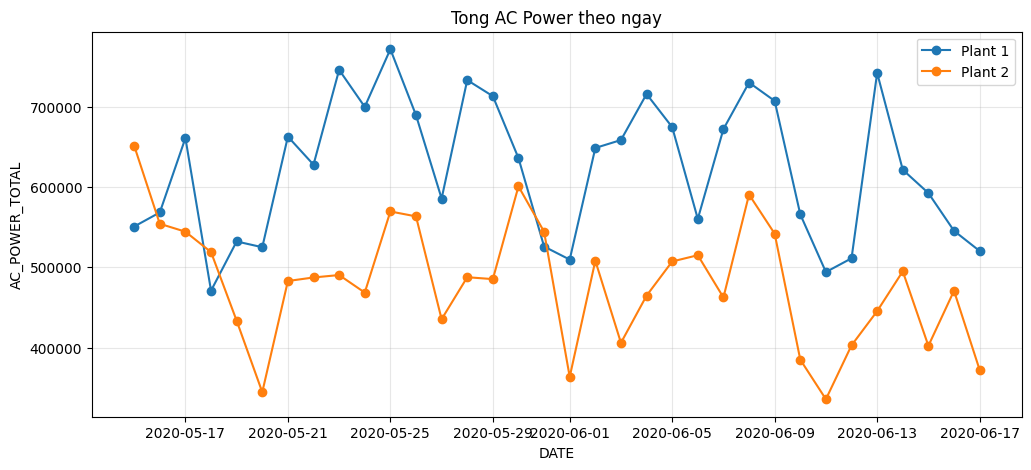

In [41]:
daily_generation = (
    generation.assign(DATE=generation['DATE_TIME'].dt.floor('D'))
    .groupby(['PLANT_NO', 'DATE'], as_index=False)
    .agg(AC_POWER_TOTAL=('AC_POWER', 'sum'), DC_POWER_TOTAL=('DC_POWER', 'sum'))
)

fig, ax = plt.subplots(figsize=(12, 5))
for plant_no, data in daily_generation.groupby('PLANT_NO'):
    ax.plot(data['DATE'], data['AC_POWER_TOTAL'], marker='o', linewidth=1.5, label=f'Plant {plant_no}')
ax.set_title('Tong AC Power theo ngay')
ax.set_xlabel('DATE')
ax.set_ylabel('AC_POWER_TOTAL')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

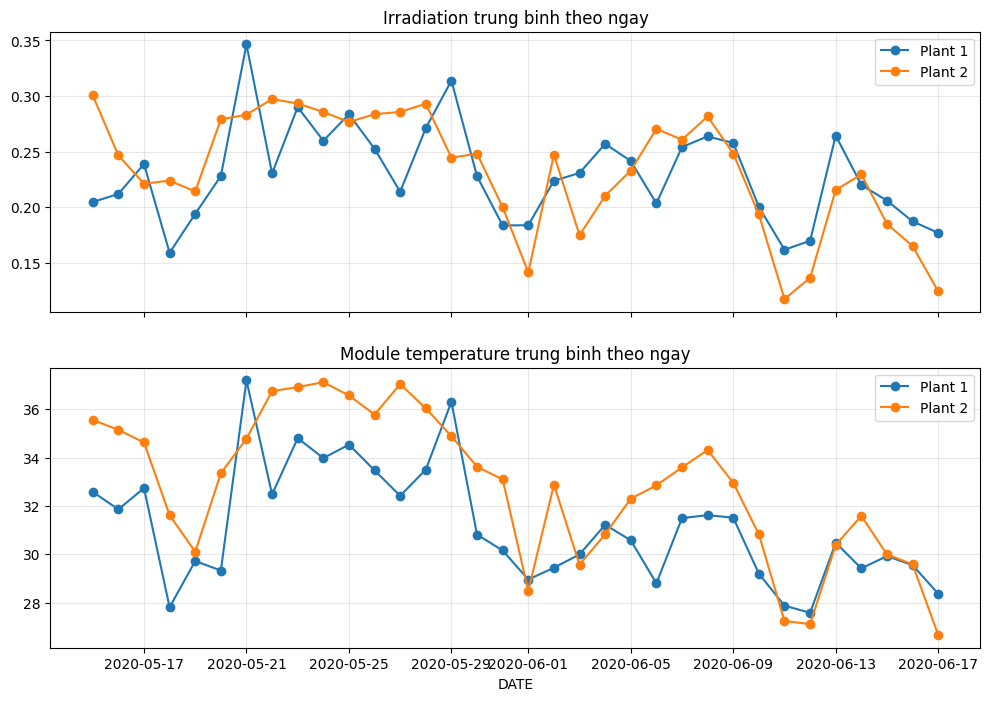

In [42]:
daily_weather = (
    weather_sensor.assign(DATE=weather_sensor['DATE_TIME'].dt.floor('D'))
    .groupby(['PLANT_NO', 'DATE'], as_index=False)
    .agg(
        IRRADIATION_MEAN=('IRRADIATION', 'mean'),
        AMBIENT_TEMPERATURE_MEAN=('AMBIENT_TEMPERATURE', 'mean'),
        MODULE_TEMPERATURE_MEAN=('MODULE_TEMPERATURE', 'mean'),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for plant_no, data in daily_weather.groupby('PLANT_NO'):
    axes[0].plot(data['DATE'], data['IRRADIATION_MEAN'], marker='o', linewidth=1.5, label=f'Plant {plant_no}')
    axes[1].plot(data['DATE'], data['MODULE_TEMPERATURE_MEAN'], marker='o', linewidth=1.5, label=f'Plant {plant_no}')
axes[0].set_title('Irradiation trung binh theo ngay')
axes[1].set_title('Module temperature trung binh theo ngay')
axes[1].set_xlabel('DATE')
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

## 6.1. Truc quan cau truc du lieu bo sung

,generation_rows,generation_timestamps,inverters,weather_rows,weather_timestamps,weather_sensors
PLANT_NO,,,,,,
1,68778,3158,22,3182,3182,1
2,67698,3259,22,3259,3259,1


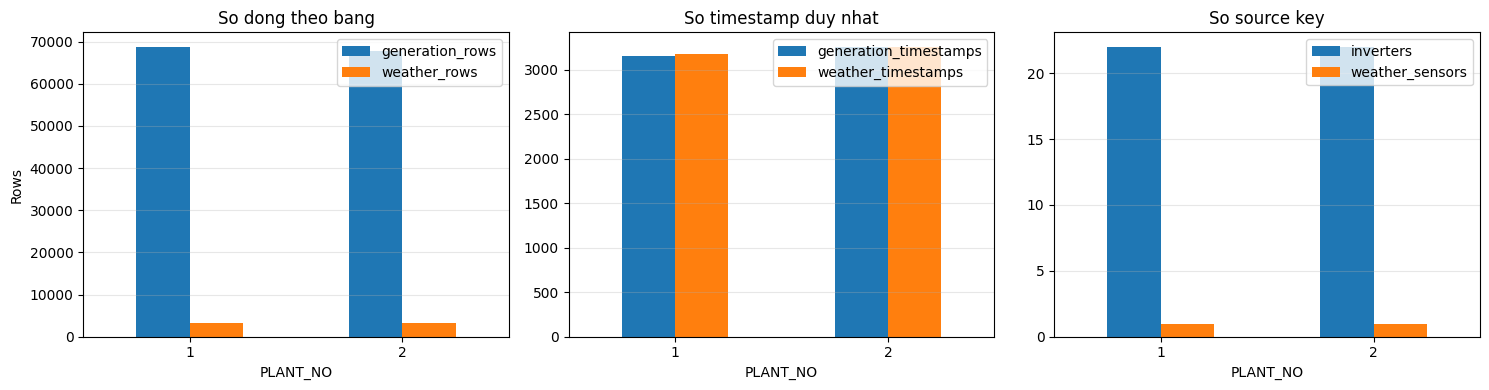

In [43]:
structure_summary = pd.concat(
    [
        generation.groupby('PLANT_NO').agg(
            generation_rows=('DATE_TIME', 'size'),
            generation_timestamps=('DATE_TIME', 'nunique'),
            inverters=('SOURCE_KEY', 'nunique'),
        ),
        weather_sensor.groupby('PLANT_NO').agg(
            weather_rows=('DATE_TIME', 'size'),
            weather_timestamps=('DATE_TIME', 'nunique'),
            weather_sensors=('SOURCE_KEY', 'nunique'),
        ),
    ],
    axis=1,
)

display(structure_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
structure_summary[['generation_rows', 'weather_rows']].plot(kind='bar', ax=axes[0])
axes[0].set_title('So dong theo bang')
axes[0].set_xlabel('PLANT_NO')
axes[0].set_ylabel('Rows')

structure_summary[['generation_timestamps', 'weather_timestamps']].plot(kind='bar', ax=axes[1])
axes[1].set_title('So timestamp duy nhat')
axes[1].set_xlabel('PLANT_NO')

structure_summary[['inverters', 'weather_sensors']].plot(kind='bar', ax=axes[2])
axes[2].set_title('So source key')
axes[2].set_xlabel('PLANT_NO')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

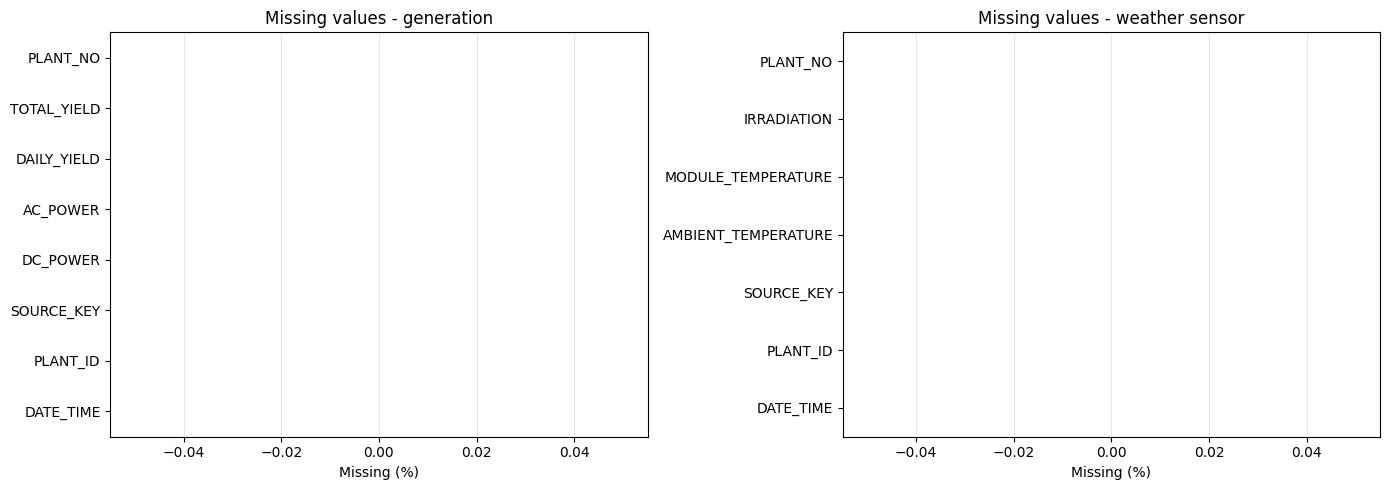

In [44]:
def plot_missing_percent(df: pd.DataFrame, title: str, ax) -> None:
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_pct.plot(kind='barh', ax=ax, color='#5b8db8')
    ax.set_title(title)
    ax.set_xlabel('Missing (%)')
    ax.grid(axis='x', alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_missing_percent(generation, 'Missing values - generation', axes[0])
plot_missing_percent(weather_sensor, 'Missing values - weather sensor', axes[1])
fig.tight_layout()
plt.show()

,table,PLANT_NO,timestamps,median_gap_min,max_gap_min,gaps_over_15_min
0,generation,1,3158,15.0,540.0,9
1,generation,2,3259,15.0,30.0,5
2,weather_sensor,1,3182,15.0,435.0,8
3,weather_sensor,2,3259,15.0,30.0,5


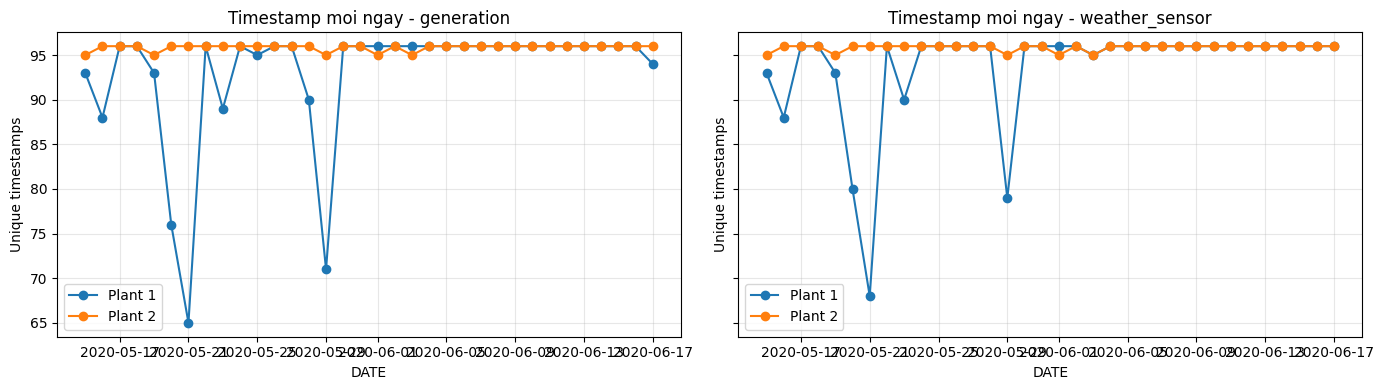

In [45]:
def timestamp_gap_table(df: pd.DataFrame, table_name: str) -> pd.DataFrame:
    rows = []
    for plant_no, data in df.groupby('PLANT_NO'):
        timestamps = data['DATE_TIME'].drop_duplicates().sort_values()
        gaps = timestamps.diff().dropna().dt.total_seconds() / 60
        rows.append(
            {
                'table': table_name,
                'PLANT_NO': plant_no,
                'timestamps': len(timestamps),
                'median_gap_min': gaps.median(),
                'max_gap_min': gaps.max(),
                'gaps_over_15_min': int((gaps > 15).sum()),
            }
        )
    return pd.DataFrame(rows)


gap_summary = pd.concat(
    [timestamp_gap_table(generation, 'generation'), timestamp_gap_table(weather_sensor, 'weather_sensor')],
    ignore_index=True,
)
display(gap_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (name, df_plot) in zip(axes, [('generation', generation), ('weather_sensor', weather_sensor)]):
    for plant_no, data in df_plot.groupby('PLANT_NO'):
        counts = data['DATE_TIME'].drop_duplicates().dt.floor('D').value_counts().sort_index()
        ax.plot(counts.index, counts.values, marker='o', linewidth=1.5, label=f'Plant {plant_no}')
    ax.set_title(f'Timestamp moi ngay - {name}')
    ax.set_xlabel('DATE')
    ax.set_ylabel('Unique timestamps')
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()

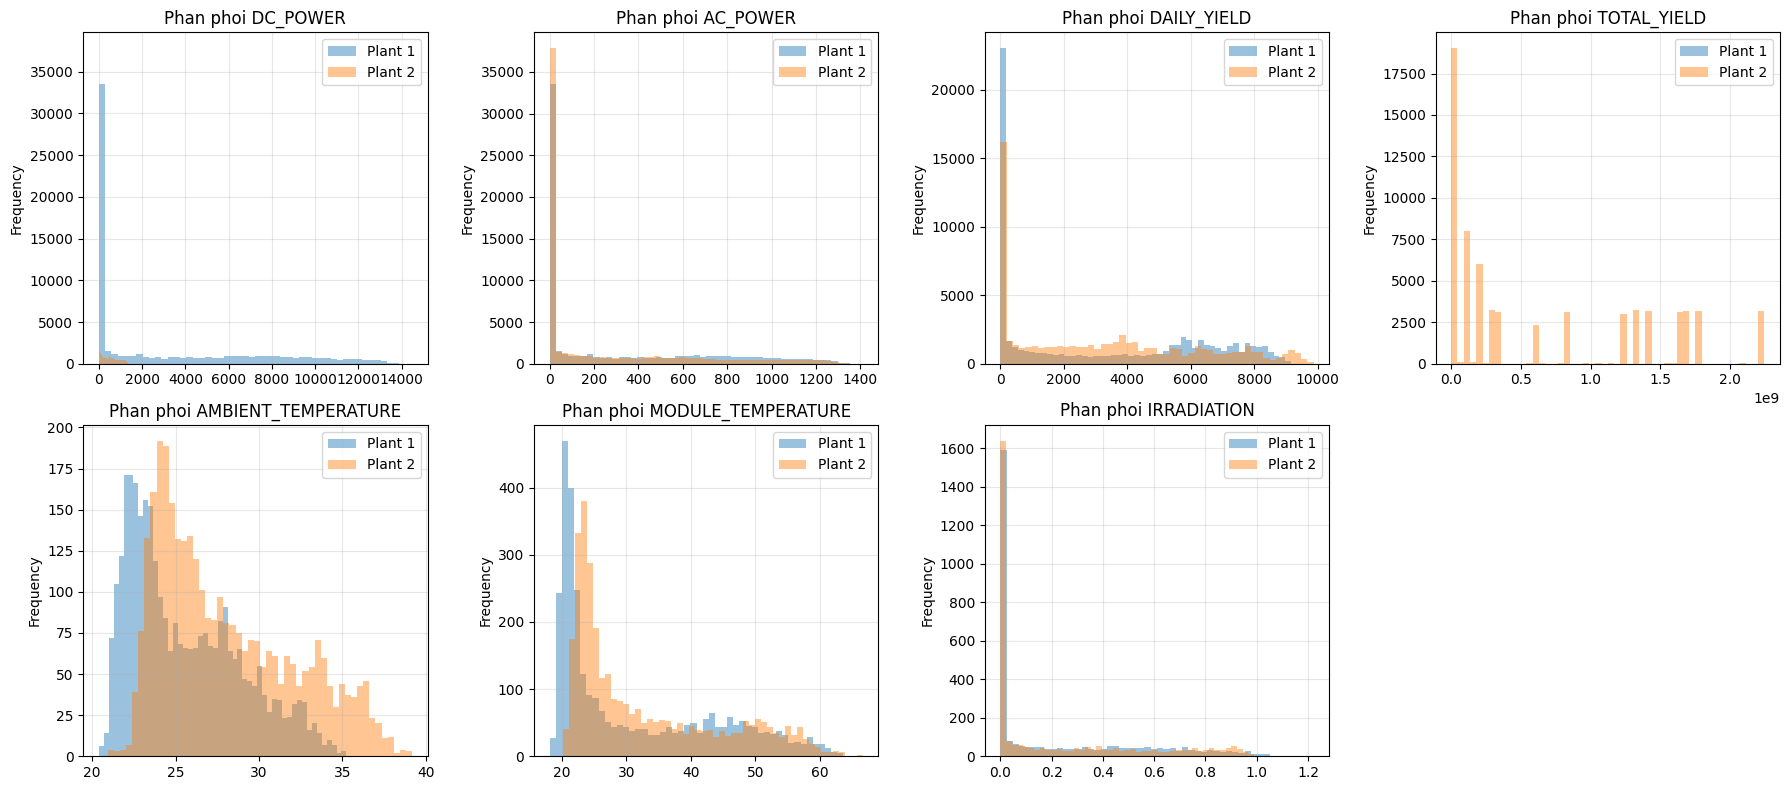

In [46]:
generation_numeric = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
weather_numeric = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes[0], generation_numeric):
    for plant_no, data in generation.groupby('PLANT_NO'):
        data[col].plot(kind='hist', bins=50, alpha=0.45, ax=ax, label=f'Plant {plant_no}')
    ax.set_title(f'Phan phoi {col}')
    ax.grid(alpha=0.3)
    ax.legend()

for ax, col in zip(axes[1], weather_numeric):
    for plant_no, data in weather_sensor.groupby('PLANT_NO'):
        data[col].plot(kind='hist', bins=50, alpha=0.45, ax=ax, label=f'Plant {plant_no}')
    ax.set_title(f'Phan phoi {col}')
    ax.grid(alpha=0.3)
    ax.legend()

axes[1, 3].axis('off')
fig.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9656\188725958.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  generation.boxplot(column=['AC_POWER', 'DC_POWER'], by='PLANT_NO', ax=axes[0])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9656\188725958.py:7: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  weather_sensor.boxplot(column=['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'], by='PLANT_NO', ax=axes[1])


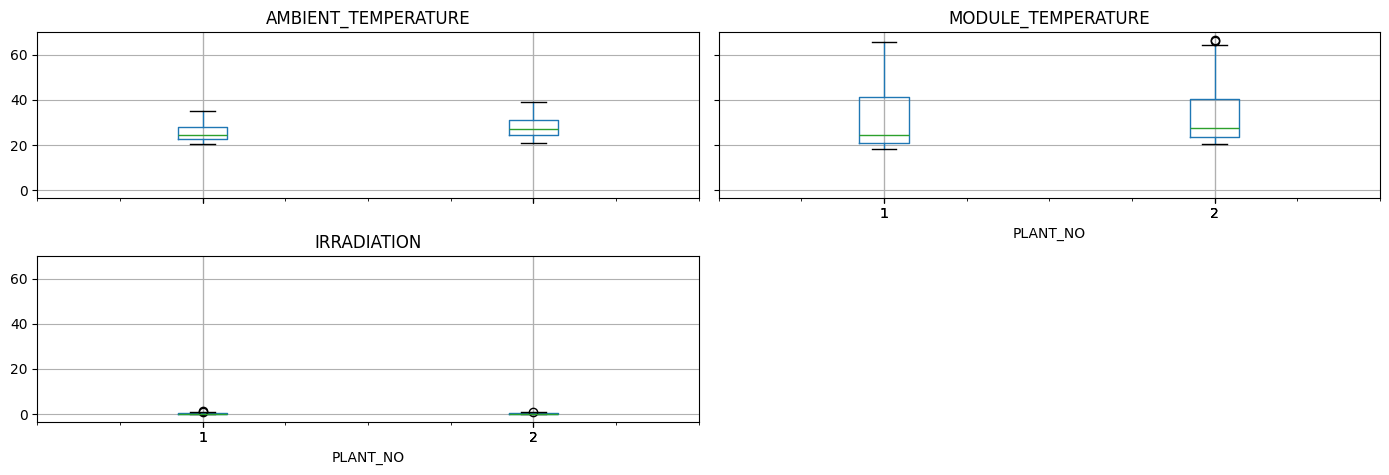

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
generation.boxplot(column=['AC_POWER', 'DC_POWER'], by='PLANT_NO', ax=axes[0])
axes[0].set_title('Boxplot cong suat theo plant')
axes[0].set_xlabel('PLANT_NO')
axes[0].set_ylabel('Power')

weather_sensor.boxplot(column=['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'], by='PLANT_NO', ax=axes[1])
axes[1].set_title('Boxplot weather sensor theo plant')
axes[1].set_xlabel('PLANT_NO')
axes[1].set_ylabel('Value')

plt.suptitle('')
for ax in axes:
    ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

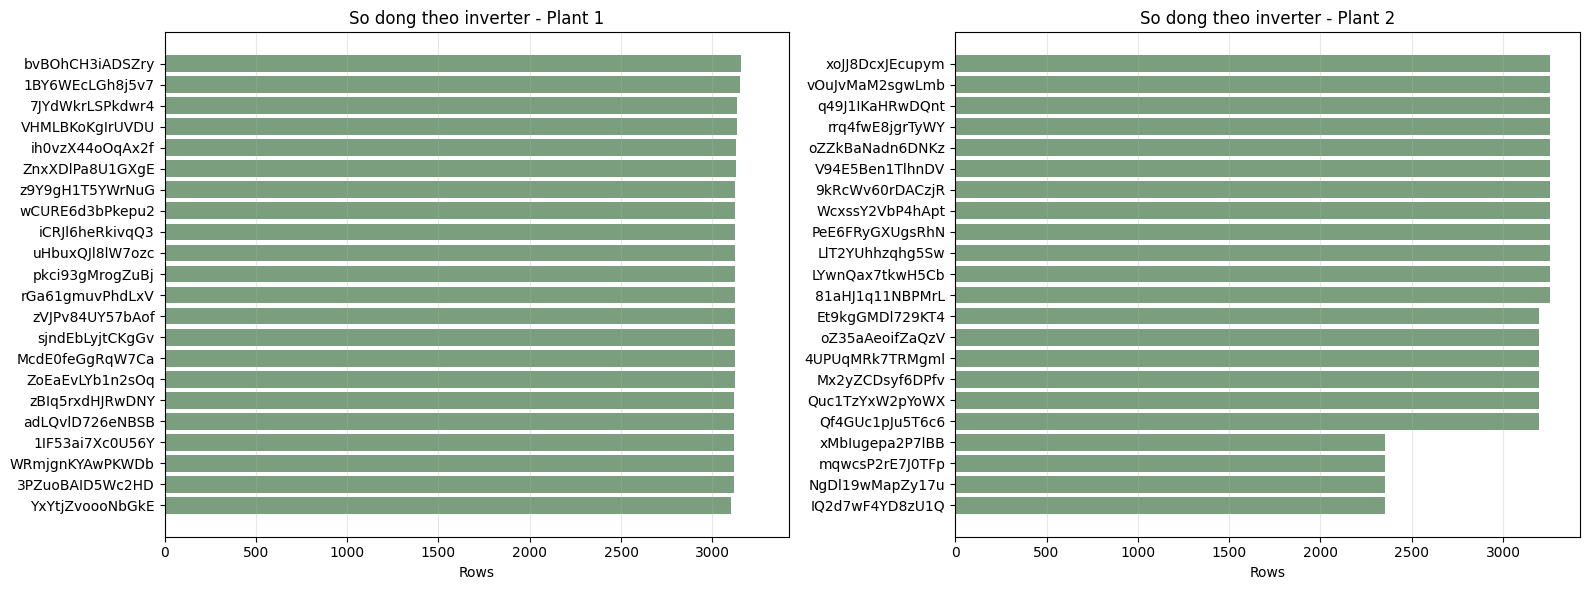

,rows_min,rows_max,ac_mean_min,ac_mean_max
PLANT_NO,,,,
1,3104,3155,276.778938,319.693862
2,2355,3259,169.644735,279.190055


In [48]:
source_counts = (
    generation.groupby(['PLANT_NO', 'SOURCE_KEY'], as_index=False)
    .agg(rows=('DATE_TIME', 'size'), timestamps=('DATE_TIME', 'nunique'), ac_mean=('AC_POWER', 'mean'))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for ax, plant_no in zip(axes, PLANTS):
    data = source_counts[source_counts['PLANT_NO'] == plant_no].sort_values('rows')
    ax.barh(data['SOURCE_KEY'], data['rows'], color='#7a9e7e')
    ax.set_title(f'So dong theo inverter - Plant {plant_no}')
    ax.set_xlabel('Rows')
    ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

display(source_counts.groupby('PLANT_NO').agg(rows_min=('rows', 'min'), rows_max=('rows', 'max'), ac_mean_min=('ac_mean', 'min'), ac_mean_max=('ac_mean', 'max')))

## 7. Tong hop generation ve cap plant/timestamp

Du lieu generation nam o cap inverter. De ghep voi weather sensor cua ca nha may, can tong hop cong suat theo `PLANT_ID`, `PLANT_NO`, `DATE_TIME` truoc.

In [49]:
generation_agg = aggregate_generation(generation)

display(generation_agg.head())
display(generation_agg.groupby('PLANT_NO').agg(rows=('DATE_TIME', 'size'), timestamps=('DATE_TIME', 'nunique')))

,PLANT_ID,PLANT_NO,DATE_TIME,DC_POWER_TOTAL,AC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,ZERO_AC_COUNT,ZERO_AC_RATIO
0,4135001,1,2020-05-15 00:00:00,0.0,0.0,0.0,143581676.0,21,21,1.0
1,4135001,1,2020-05-15 00:15:00,0.0,0.0,0.0,143581676.0,21,21,1.0
2,4135001,1,2020-05-15 00:30:00,0.0,0.0,0.0,143581676.0,21,21,1.0
3,4135001,1,2020-05-15 00:45:00,0.0,0.0,0.0,143581676.0,21,21,1.0
4,4135001,1,2020-05-15 01:00:00,0.0,0.0,0.0,150761642.0,22,22,1.0


,rows,timestamps
PLANT_NO,,
1,3158,3158
2,3259,3259


## 8. Doc du lieu Open-Meteo neu da chay `weather_api_fetcher.py`

In [50]:
def load_open_meteo_weather(plant_no: int) -> pd.DataFrame | None:
    path = API_WEATHER_DIR / f'open_meteo_weather_plant_{plant_no}.csv'
    if not path.exists():
        print(f'Chua co Open-Meteo CSV cho Plant {plant_no}: {path}')
        return None

    api_weather = pd.read_csv(path, parse_dates=['DATE_TIME'])
    api_weather['PLANT_NO'] = plant_no
    return api_weather


api_weather_frames = []
for plant_no in PLANTS:
    api_weather = load_open_meteo_weather(plant_no)
    if api_weather is not None:
        api_weather_frames.append(api_weather)

open_meteo_weather = pd.concat(api_weather_frames, ignore_index=True) if api_weather_frames else None
if open_meteo_weather is not None:
    display(open_meteo_weather.head())
    display(open_meteo_weather.groupby('PLANT_NO').agg(rows=('DATE_TIME', 'size'), timestamps=('DATE_TIME', 'nunique')))

,PLANT_NO,DATE_TIME,OM_TEMPERATURE_2M,OM_RELATIVE_HUMIDITY_2M,OM_DEW_POINT_2M,OM_APPARENT_TEMPERATURE,OM_PRESSURE_MSL,OM_SURFACE_PRESSURE,OM_PRECIPITATION,OM_CLOUD_COVER,OM_WIND_SPEED_10M,OM_WIND_DIRECTION_10M,OM_SHORTWAVE_RADIATION,OM_DIRECT_RADIATION,OM_DIFFUSE_RADIATION,OM_DIRECT_NORMAL_IRRADIANCE,OM_SUNSHINE_DURATION,LATITUDE,LONGITUDE,OPEN_METEO_TIMEZONE,OPEN_METEO_UTC_OFFSET_SECONDS
0,1,2020-05-15 00:00:00,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800
1,1,2020-05-15 00:15:00,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800
2,1,2020-05-15 00:30:00,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800
3,1,2020-05-15 00:45:00,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800
4,1,2020-05-15 01:00:00,28.6,71,22.9,32.3,1006.5,970.6,0.0,8,11.8,117,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800


,rows,timestamps
PLANT_NO,,
1,3264,3264
2,3264,3264


## 9. Ghep noi du lieu hop li

In [51]:
weather_sensor_clean = weather_sensor.rename(columns={'SOURCE_KEY': 'WEATHER_SENSOR_KEY'})

merged = generation_agg.merge(
    weather_sensor_clean,
    on=['PLANT_ID', 'PLANT_NO', 'DATE_TIME'],
    how='left',
    validate='one_to_one',
)

if open_meteo_weather is not None:
    api_cols_to_drop = [col for col in ['LATITUDE', 'LONGITUDE', 'OPEN_METEO_TIMEZONE', 'OPEN_METEO_UTC_OFFSET_SECONDS'] if col in open_meteo_weather.columns]
    api_merge = open_meteo_weather.drop(columns=api_cols_to_drop)
    merged = merged.merge(api_merge, on=['PLANT_NO', 'DATE_TIME'], how='left', validate='one_to_one')

merged = add_time_features(merged)
merged = merged.sort_values(['PLANT_NO', 'DATE_TIME']).reset_index(drop=True)

display(merged.head())
display(merged.groupby('PLANT_NO').agg(rows=('DATE_TIME', 'size'), missing_sensor_weather=('AMBIENT_TEMPERATURE', lambda s: int(s.isna().sum()))))

,PLANT_ID,PLANT_NO,DATE_TIME,DC_POWER_TOTAL,AC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,ZERO_AC_COUNT,ZERO_AC_RATIO,WEATHER_SENSOR_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,OM_TEMPERATURE_2M,OM_RELATIVE_HUMIDITY_2M,OM_DEW_POINT_2M,OM_APPARENT_TEMPERATURE,OM_PRESSURE_MSL,OM_SURFACE_PRESSURE,OM_PRECIPITATION,OM_CLOUD_COVER,OM_WIND_SPEED_10M,OM_WIND_DIRECTION_10M,OM_SHORTWAVE_RADIATION,OM_DIRECT_RADIATION,OM_DIFFUSE_RADIATION,OM_DIRECT_NORMAL_IRRADIANCE,OM_SUNSHINE_DURATION,HOUR,MINUTE,DAY,DAYOFWEEK,WEEKOFYEAR,MONTH,DAYOFYEAR,HOUR_SIN,HOUR_COS,IS_DAYLIGHT
0,4135001,1,2020-05-15 00:00:00,0.0,0.0,0.0,143581676.0,21,21,1.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,0,0,15,4,20,5,136,0.000000,1.000000,0
1,4135001,1,2020-05-15 00:15:00,0.0,0.0,0.0,143581676.0,21,21,1.0,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,0,15,15,4,20,5,136,0.065403,0.997859,0
2,4135001,1,2020-05-15 00:30:00,0.0,0.0,0.0,143581676.0,21,21,1.0,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,0,30,15,4,20,5,136,0.130526,0.991445,0
3,4135001,1,2020-05-15 00:45:00,0.0,0.0,0.0,143581676.0,21,21,1.0,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,0,45,15,4,20,5,136,0.195090,0.980785,0
4,4135001,1,2020-05-15 01:00:00,0.0,0.0,0.0,150761642.0,22,22,1.0,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,28.6,71,22.9,32.3,1006.5,970.6,0.0,8,11.8,117,0.0,0.0,0.0,0.0,0.0,1,0,15,4,20,5,136,0.258819,0.965926,0


,rows,missing_sensor_weather
PLANT_NO,,
1,3158,1
2,3259,0


## 10. Kiem tra chat luong du lieu sau merge

In [52]:
key_duplicates = merged.duplicated(['PLANT_ID', 'PLANT_NO', 'DATE_TIME']).sum()
print('Duplicate merged keys:', key_duplicates)

missing_after_merge = merged.isna().sum().sort_values(ascending=False).rename('missing').to_frame()
display(missing_after_merge[missing_after_merge['missing'] > 0])

numeric_cols = merged.select_dtypes(include='number').columns
display(merged[numeric_cols].describe().T)

Duplicate merged keys: 0


,missing
MODULE_TEMPERATURE,1
IRRADIATION,1
WEATHER_SENSOR_KEY,1
AMBIENT_TEMPERATURE,1


,count,mean,std,min,25%,50%,75%,max
PLANT_ID,6417.0,4.135509e+06,4.999770e+02,4.135001e+06,4.135001e+06,4.136001e+06,4.136001e+06,4.136001e+06
PLANT_NO,6417.0,1.507870e+00,4.999770e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
DC_POWER_TOTAL,6417.0,3.633706e+04,6.957760e+04,0.000000e+00,0.000000e+00,1.264839e+03,1.779019e+04,2.989378e+05
AC_POWER_TOTAL,6417.0,5.844489e+03,7.576456e+03,0.000000e+00,0.000000e+00,6.399071e+02,1.189813e+04,2.915021e+04
DAILY_YIELD_TOTAL,6417.0,7.008690e+04,5.778587e+04,0.000000e+00,1.060064e+04,7.159500e+04,1.206730e+05,1.937700e+05
TOTAL_YIELD_TOTAL,6417.0,7.026527e+09,6.825699e+09,0.000000e+00,1.536176e+08,9.712150e+09,1.419024e+10,1.419408e+10
ACTIVE_SOURCE_COUNT,6417.0,2.126788e+01,1.910910e+00,4.000000e+00,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01
ZERO_AC_COUNT,6417.0,1.053654e+01,1.029451e+01,0.000000e+00,0.000000e+00,8.000000e+00,2.200000e+01,2.200000e+01
ZERO_AC_RATIO,6417.0,4.990312e-01,4.808296e-01,0.000000e+00,0.000000e+00,3.888889e-01,1.000000e+00,1.000000e+00
AMBIENT_TEMPERATURE,6416.0,2.683477e+01,3.934008e+00,2.039850e+01,2.367318e+01,2.597393e+01,2.936660e+01,3.918164e+01


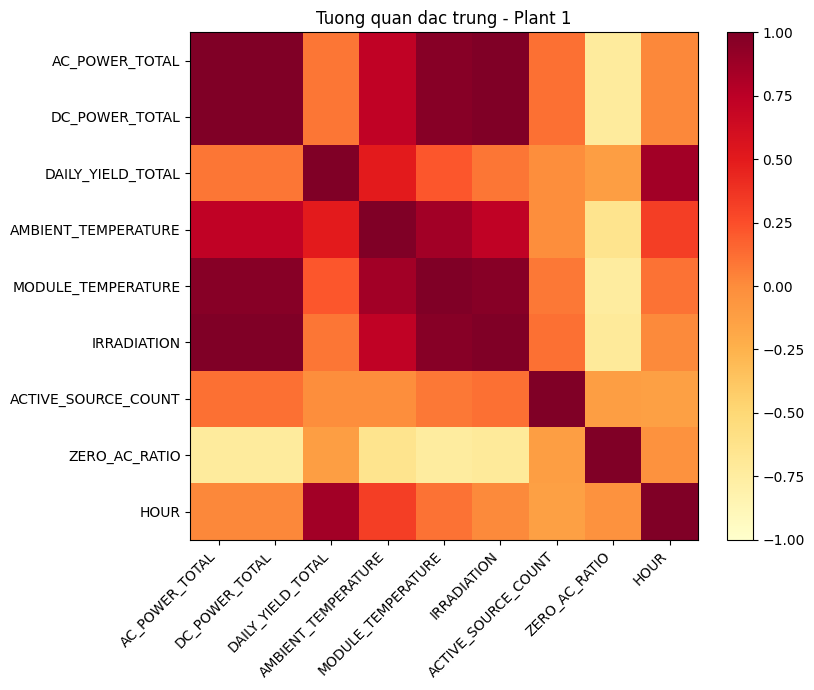

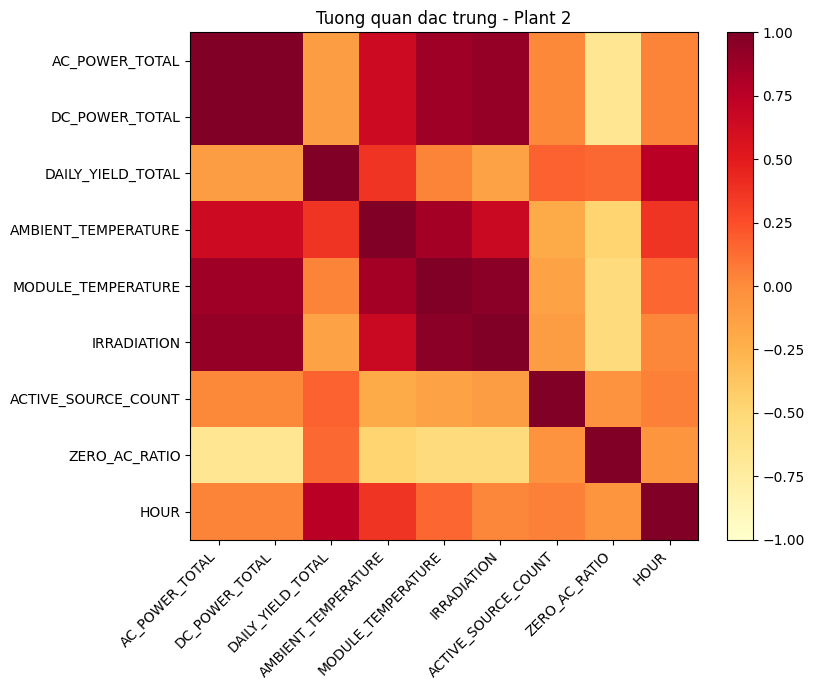

In [53]:
corr_cols = [
    'AC_POWER_TOTAL',
    'DC_POWER_TOTAL',
    'DAILY_YIELD_TOTAL',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'ACTIVE_SOURCE_COUNT',
    'ZERO_AC_RATIO',
    'HOUR',
]
corr_cols = [col for col in corr_cols if col in merged.columns]

for plant_no, data in merged.dropna(subset=['AMBIENT_TEMPERATURE', 'IRRADIATION']).groupby('PLANT_NO'):
    corr = data[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr.values, cmap='YlOrRd', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    ax.set_title(f'Tuong quan dac trung - Plant {plant_no}')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

## 11. Chuan hoa du lieu va chia train/test

Phan nay tao train/test de tai su dung trong cac notebook huan luyen sau. Viec fit median va scaler chi thuc hien tren train de tranh ro ri du lieu tu test. Phan nay khong luu train/test ra CSV.

In [54]:
TARGET_COLUMN = 'AC_POWER_TOTAL'

BASE_FEATURES = [
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'HOUR',
    'MINUTE',
    'DAYOFWEEK',
    'DAYOFYEAR',
    'MONTH',
    'HOUR_SIN',
    'HOUR_COS',
    'IS_DAYLIGHT',
]

USE_OPEN_METEO_FEATURES = True
TEST_SIZE = 0.2

open_meteo_feature_cols = [
    col for col in merged.columns
    if USE_OPEN_METEO_FEATURES and col.startswith('OM_') and pd.api.types.is_numeric_dtype(merged[col])
]

feature_columns = [col for col in BASE_FEATURES if col in merged.columns] + open_meteo_feature_cols
plant_values = sorted(int(value) for value in merged['PLANT_NO'].dropna().unique())
plant_one_hot_columns = [f'PLANT_NO_{plant_no}' for plant_no in plant_values]

model_df = merged.dropna(subset=[TARGET_COLUMN]).sort_values(['DATE_TIME', 'PLANT_NO']).reset_index(drop=True)
split_index = int(len(model_df) * (1 - TEST_SIZE))

train_df_raw = model_df.iloc[:split_index].copy()
test_df_raw = model_df.iloc[split_index:].copy()

print('Feature columns:', feature_columns)
print('Target:', TARGET_COLUMN)
print('Train rows:', len(train_df_raw), '| Test rows:', len(test_df_raw))
print('Train time:', train_df_raw['DATE_TIME'].min(), '->', train_df_raw['DATE_TIME'].max())
print('Test time :', test_df_raw['DATE_TIME'].min(), '->', test_df_raw['DATE_TIME'].max())

Feature columns: ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR', 'MINUTE', 'DAYOFWEEK', 'DAYOFYEAR', 'MONTH', 'HOUR_SIN', 'HOUR_COS', 'IS_DAYLIGHT', 'OM_TEMPERATURE_2M', 'OM_RELATIVE_HUMIDITY_2M', 'OM_DEW_POINT_2M', 'OM_APPARENT_TEMPERATURE', 'OM_PRESSURE_MSL', 'OM_SURFACE_PRESSURE', 'OM_PRECIPITATION', 'OM_CLOUD_COVER', 'OM_WIND_SPEED_10M', 'OM_WIND_DIRECTION_10M', 'OM_SHORTWAVE_RADIATION', 'OM_DIRECT_RADIATION', 'OM_DIFFUSE_RADIATION', 'OM_DIRECT_NORMAL_IRRADIANCE', 'OM_SUNSHINE_DURATION']
Target: AC_POWER_TOTAL
Train rows: 5133 | Test rows: 1284
Train time: 2020-05-15 00:00:00 -> 2020-06-11 07:00:00
Test time : 2020-06-11 07:15:00 -> 2020-06-17 23:45:00


In [55]:
feature_medians = train_df_raw[feature_columns].median(numeric_only=True)

train_df_prepared = train_df_raw.copy()
test_df_prepared = test_df_raw.copy()

for col in feature_columns:
    train_df_prepared[col] = train_df_prepared[col].fillna(feature_medians[col])
    test_df_prepared[col] = test_df_prepared[col].fillna(feature_medians[col])

scaler_mean = train_df_prepared[feature_columns].mean()
scaler_std = train_df_prepared[feature_columns].std(ddof=0).replace(0, 1)

train_df_prepared[feature_columns] = (train_df_prepared[feature_columns] - scaler_mean) / scaler_std
test_df_prepared[feature_columns] = (test_df_prepared[feature_columns] - scaler_mean) / scaler_std

for plant_no in plant_values:
    col = f'PLANT_NO_{plant_no}'
    train_df_prepared[col] = (train_df_prepared['PLANT_NO'] == plant_no).astype(int)
    test_df_prepared[col] = (test_df_prepared['PLANT_NO'] == plant_no).astype(int)

final_feature_columns = feature_columns + plant_one_hot_columns

X_train = train_df_prepared[final_feature_columns].copy()
X_test = test_df_prepared[final_feature_columns].copy()
y_train = train_df_prepared[TARGET_COLUMN].copy()
y_test = test_df_prepared[TARGET_COLUMN].copy()

train_context = train_df_prepared[['PLANT_ID', 'PLANT_NO', 'DATE_TIME', TARGET_COLUMN]].copy()
test_context = test_df_prepared[['PLANT_ID', 'PLANT_NO', 'DATE_TIME', TARGET_COLUMN]].copy()

preprocessing_metadata = {
    'target_column': TARGET_COLUMN,
    'split_method': 'time_ordered',
    'test_size': TEST_SIZE,
    'train_rows': len(X_train),
    'test_rows': len(X_test),
    'train_date_min': str(train_context['DATE_TIME'].min()),
    'train_date_max': str(train_context['DATE_TIME'].max()),
    'test_date_min': str(test_context['DATE_TIME'].min()),
    'test_date_max': str(test_context['DATE_TIME'].max()),
    'numeric_feature_columns_scaled': feature_columns,
    'plant_one_hot_columns': plant_one_hot_columns,
    'imputer': {'strategy': 'median', 'values': feature_medians.to_dict()},
    'scaler': {
        'type': 'standard',
        'mean': scaler_mean.to_dict(),
        'std': scaler_std.to_dict(),
    },
}

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('Missing X_train:', int(X_train.isna().sum().sum()))
print('Missing X_test :', int(X_test.isna().sum().sum()))
display(X_train.head())
display(y_train.head())

X_train: (5133, 28)
X_test : (1284, 28)
Missing X_train: 0
Missing X_test : 0


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,MINUTE,DAYOFWEEK,DAYOFYEAR,MONTH,HOUR_SIN,HOUR_COS,IS_DAYLIGHT,OM_TEMPERATURE_2M,OM_RELATIVE_HUMIDITY_2M,OM_DEW_POINT_2M,OM_APPARENT_TEMPERATURE,OM_PRESSURE_MSL,OM_SURFACE_PRESSURE,OM_PRECIPITATION,OM_CLOUD_COVER,OM_WIND_SPEED_10M,OM_WIND_DIRECTION_10M,OM_SHORTWAVE_RADIATION,OM_DIRECT_RADIATION,OM_DIFFUSE_RADIATION,OM_DIRECT_NORMAL_IRRADIANCE,OM_SUNSHINE_DURATION,PLANT_NO_1,PLANT_NO_2
0,-0.494981,-0.790432,-0.756396,-1.660938,-1.341310,0.492614,-1.679656,-0.791145,-0.003164,1.418356,-1.088662,-0.192661,0.501305,1.097576,0.091687,0.196593,1.086880,-0.165844,-1.103314,0.080503,-1.802878,-0.781797,-0.692853,-0.870829,-0.809607,-0.911346,1,0
1,-0.053023,-0.612675,-0.756396,-1.660938,-1.341310,0.492614,-1.679656,-0.791145,-0.003164,1.418356,-1.088662,-0.310244,-0.162838,-0.299912,-0.287055,0.877910,-0.873841,-0.165844,1.149323,-1.345415,0.473074,-0.781797,-0.692853,-0.870829,-0.809607,-0.911346,0,1
2,-0.519192,-0.798164,-0.756396,-1.660938,-0.446813,0.492614,-1.679656,-0.791145,0.089201,1.415323,-1.088662,-0.192661,0.501305,1.097576,0.091687,0.196593,1.086880,-0.165844,-1.103314,0.080503,-1.802878,-0.781797,-0.692853,-0.870829,-0.809607,-0.911346,1,0
3,-0.083115,-0.664222,-0.756396,-1.660938,-0.446813,0.492614,-1.679656,-0.791145,0.089201,1.415323,-1.088662,-0.310244,-0.162838,-0.299912,-0.287055,0.877910,-0.873841,-0.165844,1.149323,-1.345415,0.473074,-0.781797,-0.692853,-0.870829,-0.809607,-0.911346,0,1
4,-0.555326,-0.811828,-0.756396,-1.660938,0.447684,0.492614,-1.679656,-0.791145,0.181171,1.406240,-1.088662,-0.192661,0.501305,1.097576,0.091687,0.196593,1.086880,-0.165844,-1.103314,0.080503,-1.802878,-0.781797,-0.692853,-0.870829,-0.809607,-0.911346,1,0


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: AC_POWER_TOTAL, dtype: float64

In [56]:
scale_check_cols = [col for col in ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR'] if col in X_train.columns]
display(X_train[scale_check_cols].agg(['mean', 'std']).round(4))
display(pd.Series(preprocessing_metadata, name='value').astype(str).to_frame())

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR
mean,-0.0000,-0.0000,0.0000,0.0000
std,1.0001,1.0001,1.0001,1.0001


,value
target_column,AC_POWER_TOTAL
split_method,time_ordered
test_size,0.2
train_rows,5133
test_rows,1284
train_date_min,2020-05-15 00:00:00
train_date_max,2020-06-11 07:00:00
test_date_min,2020-06-11 07:15:00
test_date_max,2020-06-17 23:45:00
numeric_feature_columns_scaled,"['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', ..."


## 12. Luu file merged EDA neu can

Train/test da chuan hoa duoc giu trong cac bien `X_train`, `X_test`, `y_train`, `y_test`. Cell duoi chi luu file merged plant-level khi can chia se hoac dung lai ngoai notebook.

In [57]:
SAVE_MERGED_CSV = False

if SAVE_MERGED_CSV:
    merged.to_csv(OUTPUT_DIR / 'eda_all_plants_merged.csv', index=False)

    for plant_no, data in merged.groupby('PLANT_NO'):
        data.to_csv(OUTPUT_DIR / f'eda_plant_{plant_no}_merged.csv', index=False)

    print('Da luu:')
    print(OUTPUT_DIR / 'eda_all_plants_merged.csv')
    for plant_no in PLANTS:
        print(OUTPUT_DIR / f'eda_plant_{plant_no}_merged.csv')
else:
    print('Khong luu CSV. Du lieu train/test dang nam trong bien X_train, X_test, y_train, y_test.')

Khong luu CSV. Du lieu train/test dang nam trong bien X_train, X_test, y_train, y_test.
